# SkillLens AI — Exploratory Data Analysis (EDA)

**Stage 2 of the SkillLens AI project.**

This notebook explores the synthetic student dataset (`student_data.csv`) before any preprocessing, clustering, or model training happens. The goal here is only to understand the data — its shape, distributions, and relationships — not to build anything yet.

**Important:** `generation_reference.csv` is intentionally **not** loaded anywhere in this notebook. It exists only to internally validate the synthetic data generator (see `ml/data/raw/DATASET_NOTES.md`) and must never influence feature analysis or modeling — using it here would be a form of data leakage.

## 1. Import Libraries

We only need four libraries for this notebook: `pandas` for tabular data, `numpy` for numeric operations, and `matplotlib`/`seaborn` for plotting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Keep plots simple and readable
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load student_data.csv

This is the only data file we load in this notebook. `generation_reference.csv` is deliberately never read here.

In [2]:
data = pd.read_csv("../data/raw/student_data.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Dataset Shape

`shape` tells us (number of rows, number of columns) — how many students and how many columns (9 features + student_id) we have.

In [3]:
data.shape

(300, 10)

## 4. First 5 Rows

A quick visual check of what the actual data looks like.

In [4]:
data.head()

,student_id,cgpa,coding_skill,dsa_skill,math_aptitude,communication_skill,security_knowledge,projects_count,internships_count,certifications_count
0,1,7.3,9.4,9.1,5.7,5.9,6.7,6,2,2
1,2,6.6,4.4,3.1,5.4,5.1,2.0,1,0,1
2,3,7.3,7.7,10.0,7.3,3.5,5.1,6,1,2
3,4,6.0,6.1,2.5,3.4,3.5,3.7,2,0,0
4,5,8.3,9.4,9.2,6.7,4.3,5.6,5,2,2


## 5. Column Names and Data Types

Checking that every column has the data type we expect (numbers, not text) before doing any analysis.

In [5]:
print("Column names:")
print(data.columns.tolist())
print()
print("Data types:")
print(data.dtypes)

Column names:
['student_id', 'cgpa', 'coding_skill', 'dsa_skill', 'math_aptitude', 'communication_skill', 'security_knowledge', 'projects_count', 'internships_count', 'certifications_count']

Data types:
student_id                int64
cgpa                    float64
coding_skill            float64
dsa_skill               float64
math_aptitude           float64
communication_skill     float64
security_knowledge      float64
projects_count            int64
internships_count         int64
certifications_count      int64
dtype: object


## 6. Missing-Value Check

Counting how many empty/missing values exist in each column. If this dataset needed cleaning, this is where we'd find out.

In [6]:
data.isnull().sum()

student_id              0
cgpa                    0
coding_skill            0
dsa_skill               0
math_aptitude           0
communication_skill     0
security_knowledge      0
projects_count          0
internships_count       0
certifications_count    0
dtype: int64

## 7. Duplicate-Row Check

Two checks: exact duplicate rows (including `student_id`, which should never happen since IDs are unique), and duplicate skill profiles ignoring `student_id` (two different students who happen to have identical scores on every feature).

In [7]:
duplicate_rows_full = data.duplicated().sum()
duplicate_rows_features_only = data.drop(columns=["student_id"]).duplicated().sum()

print(f"Fully duplicate rows (including student_id): {duplicate_rows_full}")
print(f"Duplicate skill profiles (ignoring student_id): {duplicate_rows_features_only}")

Fully duplicate rows (including student_id): 0
Duplicate skill profiles (ignoring student_id): 0


## 8. Descriptive Statistics

Mean, standard deviation, min, max, and quartiles for every feature. `student_id` is excluded since it's just an identifier, not a measurement.

In [8]:
# List of the 9 skill features, used throughout the rest of this notebook.
features = [
    "cgpa", "coding_skill", "dsa_skill", "math_aptitude", "communication_skill",
    "security_knowledge", "projects_count", "internships_count", "certifications_count",
]

data[features].describe()

,cgpa,coding_skill,dsa_skill,math_aptitude,communication_skill,security_knowledge,projects_count,internships_count,certifications_count
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,6.971667,6.559333,6.184333,6.262000,5.456333,5.630333,4.026667,1.146667,1.956667
std,1.420572,2.220371,2.353519,1.919419,1.777374,2.070815,2.141942,1.132592,1.545775
min,2.800000,0.100000,0.100000,0.500000,0.900000,0.000000,0.000000,0.000000,0.000000
25%,5.975000,4.975000,4.400000,5.000000,4.200000,4.100000,3.000000,0.000000,1.000000
50%,7.000000,6.850000,6.200000,6.350000,5.250000,5.550000,4.000000,1.000000,2.000000
75%,7.900000,8.400000,8.225000,7.800000,6.625000,7.000000,6.000000,2.000000,3.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,4.000000,5.000000


## 9. Feature Distributions

A histogram for each of the 9 features, to see how values are spread out (e.g., are most students average, or is there a wide spread?).

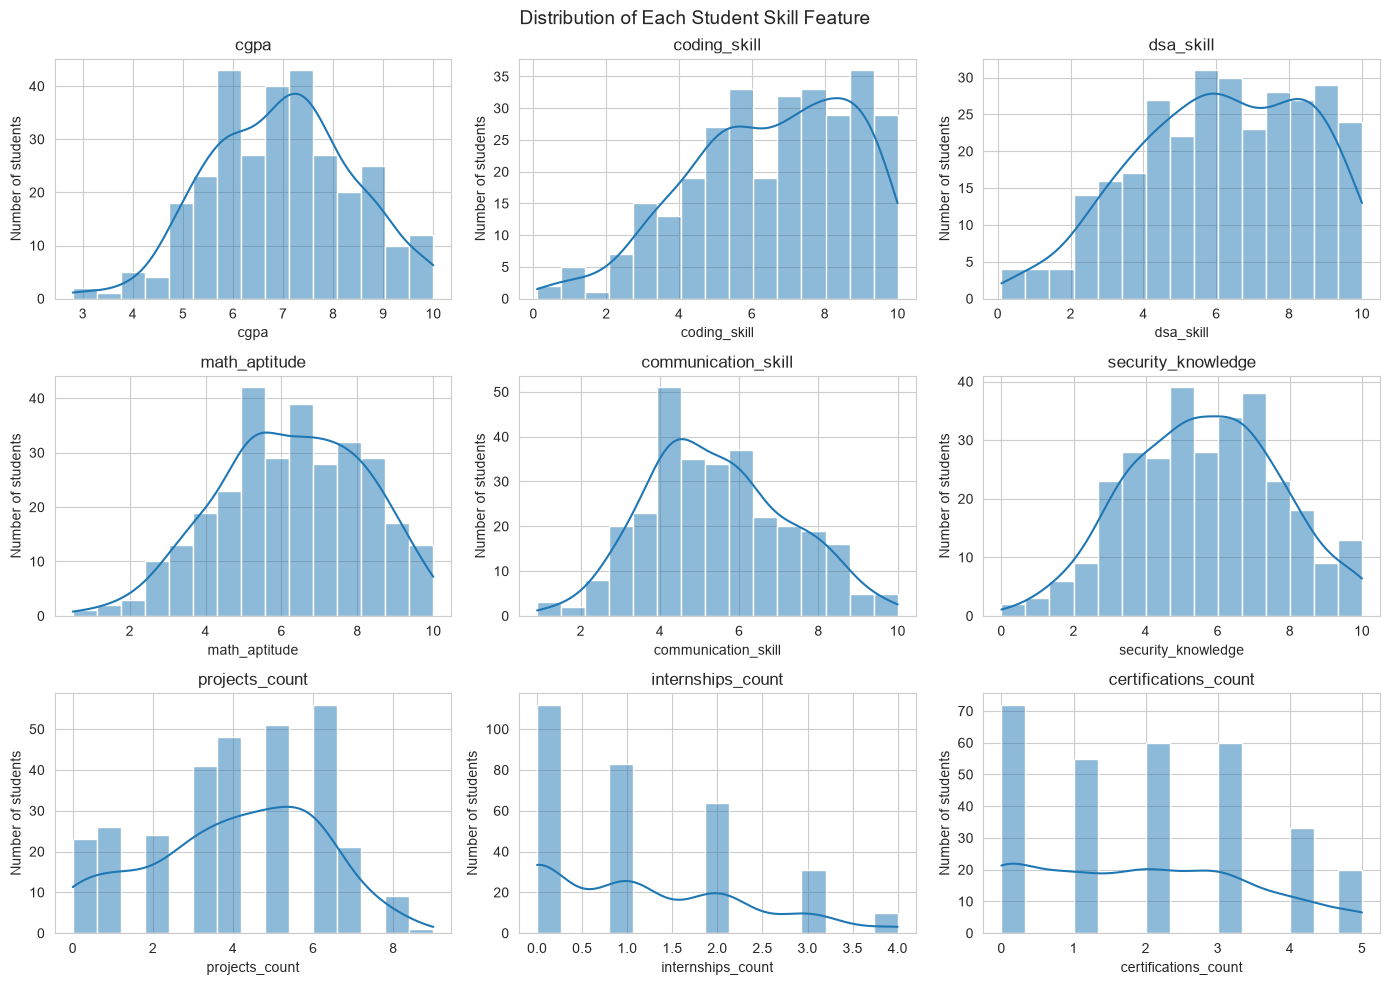

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(data[feature], bins=15, kde=True, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Number of students")

fig.suptitle("Distribution of Each Student Skill Feature", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Box Plots for Numerical Features

Box plots show the median, the middle 50% of values (the box), and any outliers (points beyond the whiskers) for each feature.

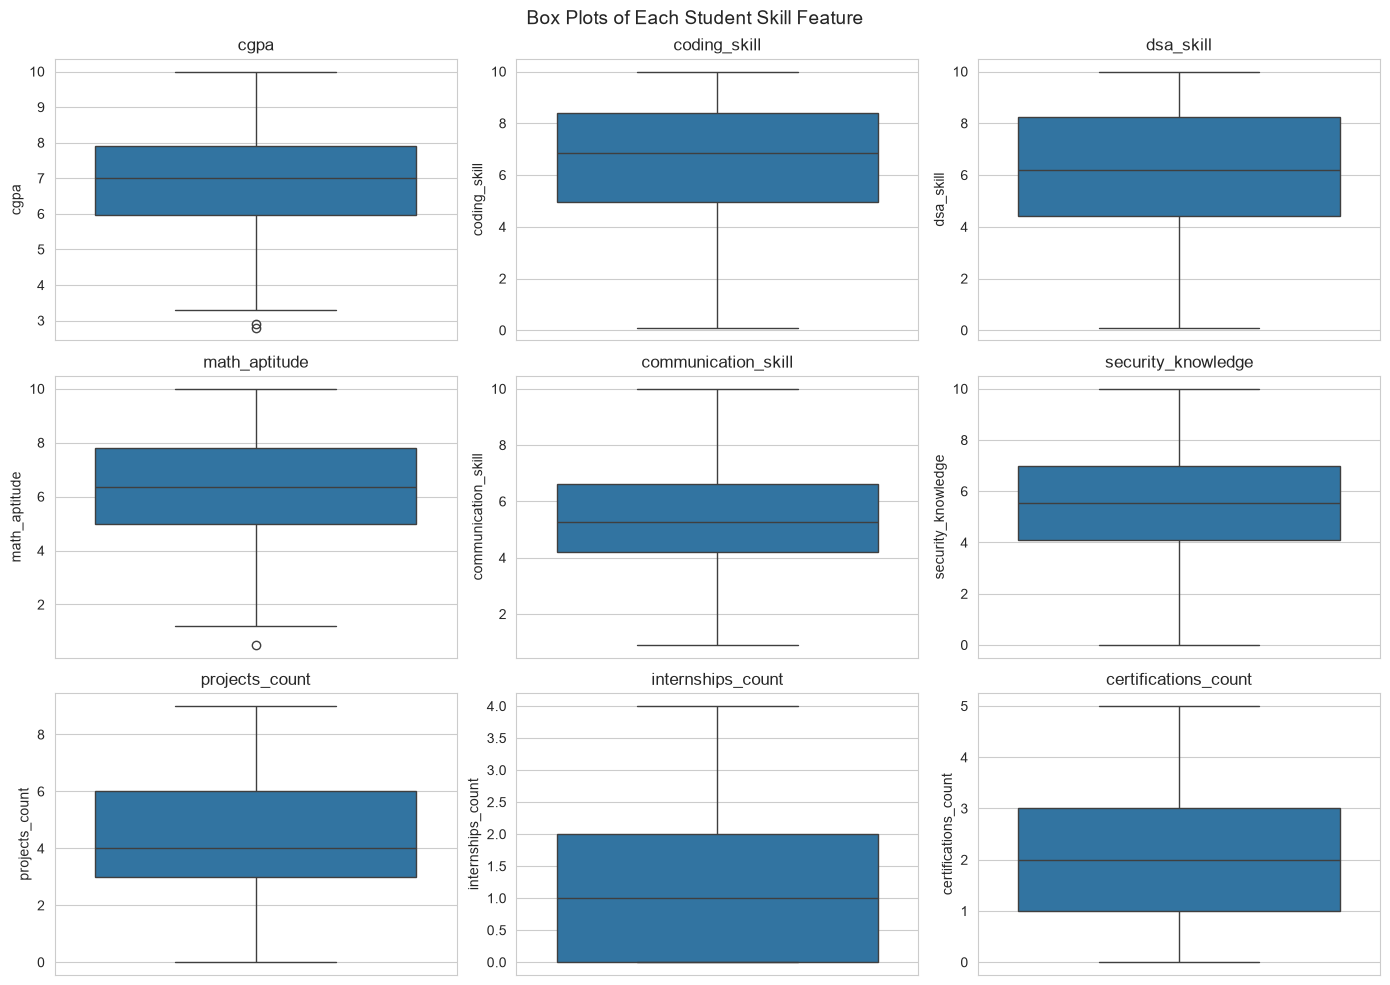

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(y=data[feature], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_ylabel(feature)

fig.suptitle("Box Plots of Each Student Skill Feature", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Correlation Matrix / Heatmap

`corr()` measures how strongly each pair of features moves together, from -1 (perfectly opposite) to +1 (perfectly together). This matters later: highly correlated features carry overlapping information, which is part of why PCA (dimensionality reduction) is useful.

In [11]:
correlation_matrix = data[features].corr()
correlation_matrix

,cgpa,coding_skill,dsa_skill,math_aptitude,communication_skill,security_knowledge,projects_count,internships_count,certifications_count
cgpa,1.000000,0.479018,0.431424,0.446520,0.356026,0.305063,0.445076,0.196534,0.392086
coding_skill,0.479018,1.000000,0.746134,0.648047,0.251205,0.434879,0.691712,0.275016,0.474039
dsa_skill,0.431424,0.746134,1.000000,0.671120,0.202724,0.351853,0.683164,0.244401,0.376181
math_aptitude,0.446520,0.648047,0.671120,1.000000,0.279264,0.344452,0.639812,0.230572,0.419675
communication_skill,0.356026,0.251205,0.202724,0.279264,1.000000,0.158189,0.268601,0.110519,0.248129
security_knowledge,0.305063,0.434879,0.351853,0.344452,0.158189,1.000000,0.451547,0.225826,0.535986
projects_count,0.445076,0.691712,0.683164,0.639812,0.268601,0.451547,1.000000,0.287895,0.494301
internships_count,0.196534,0.275016,0.244401,0.230572,0.110519,0.225826,0.287895,1.000000,0.250075
certifications_count,0.392086,0.474039,0.376181,0.419675,0.248129,0.535986,0.494301,0.250075,1.000000


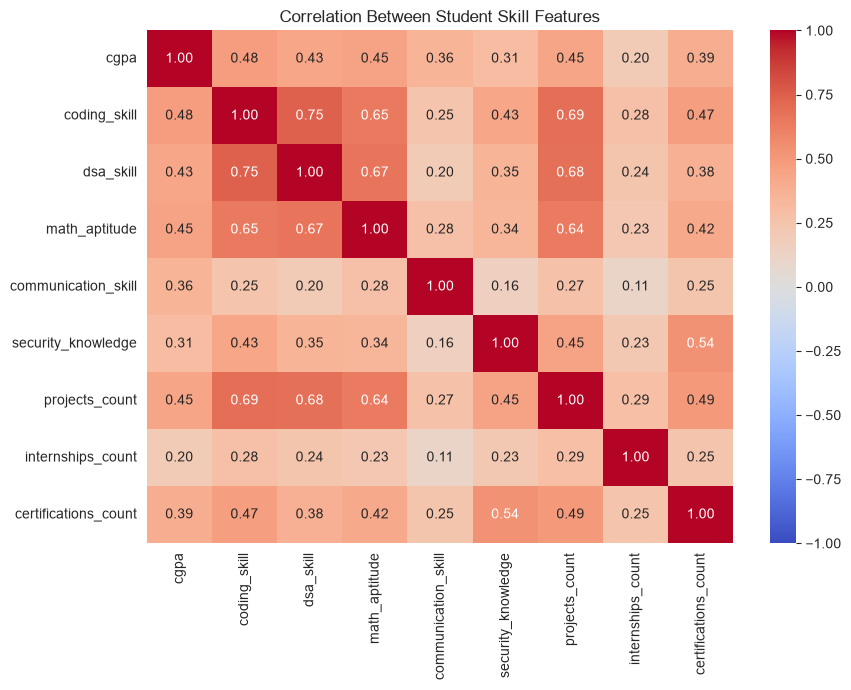

In [12]:
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Student Skill Features")
plt.tight_layout()
plt.show()

## 12. Brief Observations from the EDA

Before writing conclusions in words, we compute a few supporting numbers: which features vary the most, which features have outliers (using the standard IQR rule also shown in the box plots above), and which feature pairs are most strongly correlated.

In [13]:
# Which features vary the most? (raw standard deviation)
print("Standard deviation per feature (highest variation first):")
print(data[features].std().sort_values(ascending=False))

# Feature ranges differ a lot (skills are 0-10, counts are much smaller),
# so raw standard deviation alone doesn't tell the full story - ranges matter too.
print()
print("Range (max - min) per feature:")
print((data[features].max() - data[features].min()).sort_values(ascending=False))

# Outlier count per feature using the IQR method (same rule box plots use)
print()
print("Outlier count per feature (IQR method):")
for feature in features:
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((data[feature] < lower_bound) | (data[feature] > upper_bound)).sum()
    print(f"  {feature}: {outlier_count} outliers")

# Strongest correlations between different (non-identical) features
print()
print("Feature pairs with correlation strength 0.6 or higher:")
corr_pairs = correlation_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove each feature's correlation with itself
strong_pairs = corr_pairs[corr_pairs >= 0.6].sort_values(ascending=False)
print(strong_pairs.drop_duplicates())

Standard deviation per feature (highest variation first):
dsa_skill               2.353519
coding_skill            2.220371
projects_count          2.141942
security_knowledge      2.070815
math_aptitude           1.919419
communication_skill     1.777374
certifications_count    1.545775
cgpa                    1.420572
internships_count       1.132592
dtype: float64

Range (max - min) per feature:
security_knowledge      10.0
dsa_skill                9.9
coding_skill             9.9
math_aptitude            9.5
communication_skill      9.1
projects_count           9.0
cgpa                     7.2
certifications_count     5.0
internships_count        4.0
dtype: float64

Outlier count per feature (IQR method):
  cgpa: 2 outliers
  coding_skill: 0 outliers
  dsa_skill: 0 outliers
  math_aptitude: 1 outliers
  communication_skill: 0 outliers
  security_knowledge: 0 outliers
  projects_count: 0 outliers
  internships_count: 0 outliers
  certifications_count: 0 outliers

Feature pairs with 

**Observations (based on the actual output above):**

- **Highest variation:** `dsa_skill` (std ≈ 2.35) and `coding_skill` (std ≈ 2.22) vary the most, `internships_count` (std ≈ 1.13) varies the least. Raw standard deviation isn't fully comparable across features though, since skill scores range 0–10 while counts range 0–4/0–5 — a smaller absolute spread on a smaller-range feature isn't necessarily "less varied" in relative terms.
- **Missing values:** none. Every column has 0 missing values.
- **Duplicate rows:** none. 0 fully duplicate rows and 0 duplicate skill profiles (even ignoring `student_id`).
- **Strongly correlated features:** six pairs have correlation ≥ 0.6 — `coding_skill`↔`dsa_skill` (0.75), `coding_skill`↔`projects_count` (0.69), `dsa_skill`↔`projects_count` (0.68), `dsa_skill`↔`math_aptitude` (0.67), `coding_skill`↔`math_aptitude` (0.65), `math_aptitude`↔`projects_count` (0.64). These four features (coding, DSA, math, projects) move together — students who are strong in one tend to be strong in the others.
- **Outliers (IQR method):** very few — `cgpa` has 2, `math_aptitude` has 1, all other 7 features have 0. The dataset does not have widespread extreme outliers.
- **Feature scales/ranges:** ranges differ noticeably — skill scores span roughly 0–10 (e.g., `security_knowledge` range = 10.0), while count features span only 0–4 or 0–5 (`internships_count` range = 4.0, `certifications_count` range = 5.0). These are not on comparable scales.
- **Standardization needed for K-Means/DBSCAN:** yes. Since K-Means and DBSCAN both work by measuring distance between points, and our features have different ranges (some 0–10, some 0–5, some 0–4), a feature like `security_knowledge` would dominate the distance calculation purely because its numbers are bigger — not because it's more important. `StandardScaler` (planned for Stage 3) fixes this by putting every feature on the same scale before any distance-based algorithm is applied.

## 13. EDA Conclusion

The dataset (300 synthetic students, 9 features) is clean: no missing values and no duplicate rows, so no cleaning step is required before moving forward. Value ranges are all valid (no negative scores, nothing above 10, no impossible counts).

Four features — `coding_skill`, `dsa_skill`, `math_aptitude`, and `projects_count` — are moderately-to-strongly correlated with each other (0.64–0.75), meaning they carry some overlapping information. This is expected given how the synthetic data was generated (technically-strong archetypes score high on all of these together), and it's a reasonable, real motivation for using PCA later to reduce redundancy for visualization.

Outliers are minimal (only 3 total, across `cgpa` and `math_aptitude`), so no special outlier-handling step is needed at this stage.

The most important finding for the next stage: **features are on very different scales** (skill scores 0–10 vs. counts 0–5 or 0–4). Since K-Means and DBSCAN are distance-based algorithms, this means **standardization (scaling all features to the same range) is necessary before clustering** — otherwise features with naturally larger numbers would unfairly dominate the distance calculations. This will be done in Stage 3 preprocessing, fitted only on the training split, per the leakage-safe workflow already agreed for this project.

No target column, K-Means clustering, or classifier has been created in this notebook — this stage was EDA only, as planned.